# Aggregated Scalar Conclusions

- Experiment generation under `agentic/scalar_experiments/outputs/`
- Aggregation via `agentic/scalar_experiments/scripts/aggregate_conclusions.py`

Assumes `agentic/scalar_experiments/aggregated_results.csv` exists.

In [1]:
# imports
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from copy import deepcopy

# set plotting style and pandas options
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

# define paths
BASE_DIR = Path("..").resolve()
CSV_PATH = BASE_DIR / "aggregated_results" / "aggregated_results.csv"

In [2]:
if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Expected aggregated results at {CSV_PATH}. "
        "Run scripts/aggregate_conclusions.py first."
    )

# keep_default_na=False so the literal "null" in distribution is not read as NaN
df = pd.read_csv(CSV_PATH, keep_default_na=False)
datasets = sorted(df["dataset"].unique())
print(f"Found {len(datasets)} datasets: {datasets}")
df

Found 5 datasets: ['affairs', 'amtl', 'boxes', 'caschools', 'crofoot']


,dataset,distribution,perturbation,run_id,response,explanation
0,affairs,alt,add_features,1,10,The research question asks whether having chil...
1,affairs,alt,add_features,2,40,Among the 601 married individuals in this data...
2,affairs,alt,add_features,3,10,Using 601 married individuals from the affairs...
3,affairs,alt,add_features,4,40,Research question: Does having children decrea...
4,affairs,alt,add_features,5,5,Using the 1969 Psychology Today extramarital a...
...,...,...,...,...,...,...
920,crofoot,null,shuffle_names,16,15,Our analysis modeled the probability that the ...
921,crofoot,null,shuffle_names,17,20,Research question: Do relative group size and ...
922,crofoot,null,shuffle_names,18,20,"Using 58 intergroup contests, I modeled a bina..."
923,crofoot,null,shuffle_names,19,20,Using logistic regression models on 58 intergr...


In [3]:
# get summary stats for distributions across datasets
null_scores = df.loc[df["distribution"] == "null", "response"].reset_index(
    drop=True
)
alt_scores = df.loc[df["distribution"] == "alt", "response"].reset_index(
    drop=True
)
print(
    f"null  n={len(null_scores):,}  mean={null_scores.mean():.2f}  median={null_scores.median():.2f}  std={null_scores.std():.2f}"
)
print(
    f"alt   n={len(alt_scores):,}  mean={alt_scores.mean():.2f}  median={alt_scores.median():.2f}  std={alt_scores.std():.2f}"
)

null  n=500  mean=25.75  median=20.00  std=16.30
alt   n=425  mean=49.91  median=40.00  std=31.10


In [4]:
# random number generator for permutation tests
rng = np.random.default_rng(42)
# grid for turning the discrete distributions into continuous distributions for the overlap coefficient
X_GRID = np.linspace(0, 100, 1000)
# number of permutations for permutation tests
N_PERM = 2000


def tail_mass_pvalue(null: pd.Series, threshold: float) -> float:
    """
    Gets the area under the null distribution to the right of some threshold.
    This is the p-value for a one-sided test where the null hypothesis is that
    the observed score is drawn from the null distribution, and the alternative
    is that it is drawn from some distribution to the right.
    """
    return (null >= threshold).sum() / len(null)


def overlap_coefficient(
    a: np.ndarray, b: np.ndarray, x_grid: np.ndarray = X_GRID
) -> float:
    """
    Gets the area of overlap between two distributions, where the distributions
    are estimated using Gaussian KDE. The overlap coefficient is a measure of
    similarity between two distributions, and ranges from 0 (no overlap) to 1
    (complete overlap).
    """
    kde_a = stats.gaussian_kde(a)
    kde_b = stats.gaussian_kde(b)
    return float(np.trapz(np.minimum(kde_a(x_grid), kde_b(x_grid)), x_grid))


def overlap_permutation_test(
    null: np.ndarray,
    alt: np.ndarray,
    observed_ovl: float,
    n_perm: int = N_PERM,
    rng: np.random.Generator = rng,
) -> float:
    """
    Performs a permutation test to get a p-value for the observed overlap coefficient.
    The null hypothesis is that the two distributions are the same, and the alternative
    is that they are different. We shuffle the labels of the combined data, recompute
    the overlap coefficient, and see how often we get an overlap coefficient as low
    as the observed one (since lower OVL means more separation).
    """
    null = deepcopy(null)
    alt = deepcopy(alt)
    combined = np.concatenate([null, alt])
    count_extreme = 0
    perm_ovls = []
    for _ in range(n_perm):
        rng.shuffle(combined)
        perm_null = combined[: len(null)]
        perm_alt = combined[len(null) :]
        perm_ovl = overlap_coefficient(perm_null, perm_alt)
        if perm_ovl <= observed_ovl:
            count_extreme += 1
        perm_ovls.append(perm_ovl)
    return count_extreme / n_perm, perm_ovls


DATASET: 'affairs'
                n   mean  median        std
distribution                               
alt           100  20.53    15.0  14.797253
null          100  30.45    25.0  19.123403


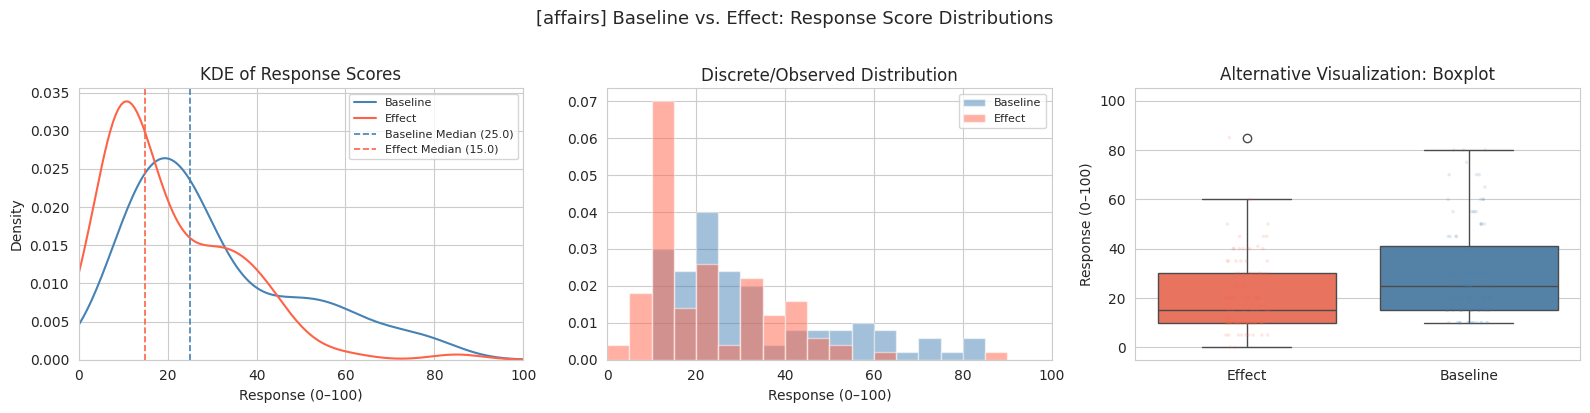

Median of Effect Distribution: 15.00  →  p-value of 0.8500 in right tail of Baseline.
Mean of Effect Distribution: 20.53  →  p-value of 0.5300 in right tail of Baseline.


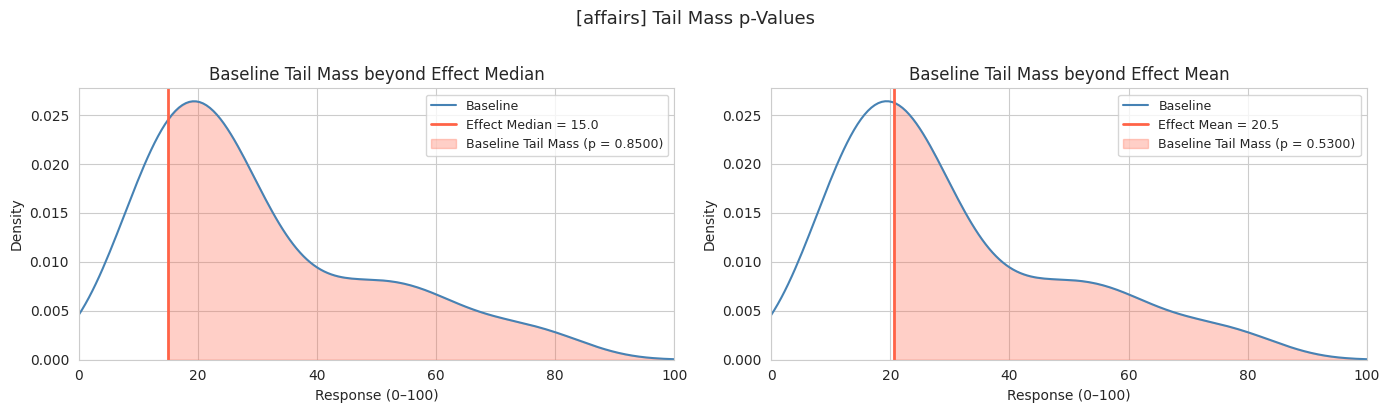

Area of Overlap: 0.7459 → p-Value of 0.0000.


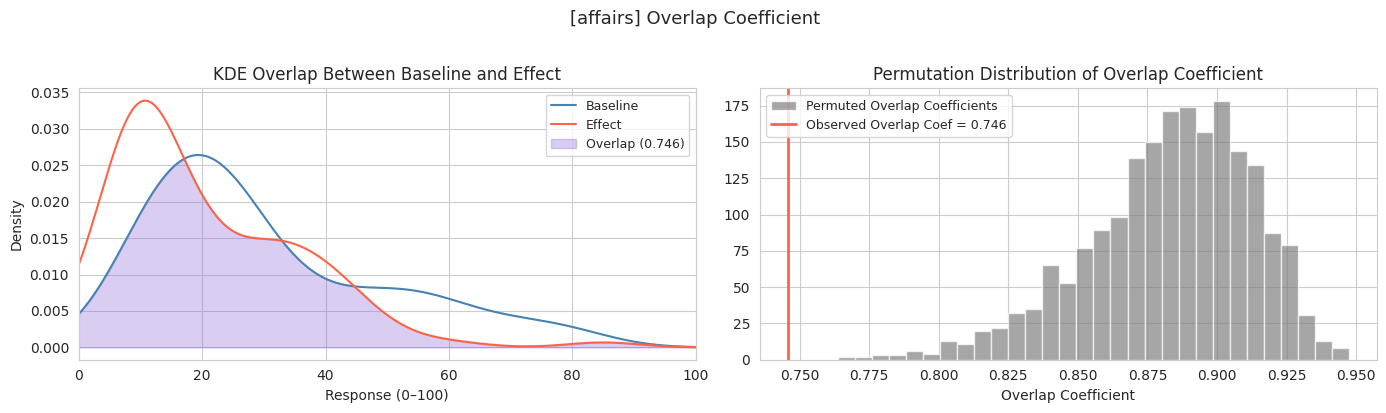


DATASET: 'amtl'
                n   mean  median        std
distribution                               
alt           100  93.85    95.0   6.557246
null          100  26.50    20.0  16.504973


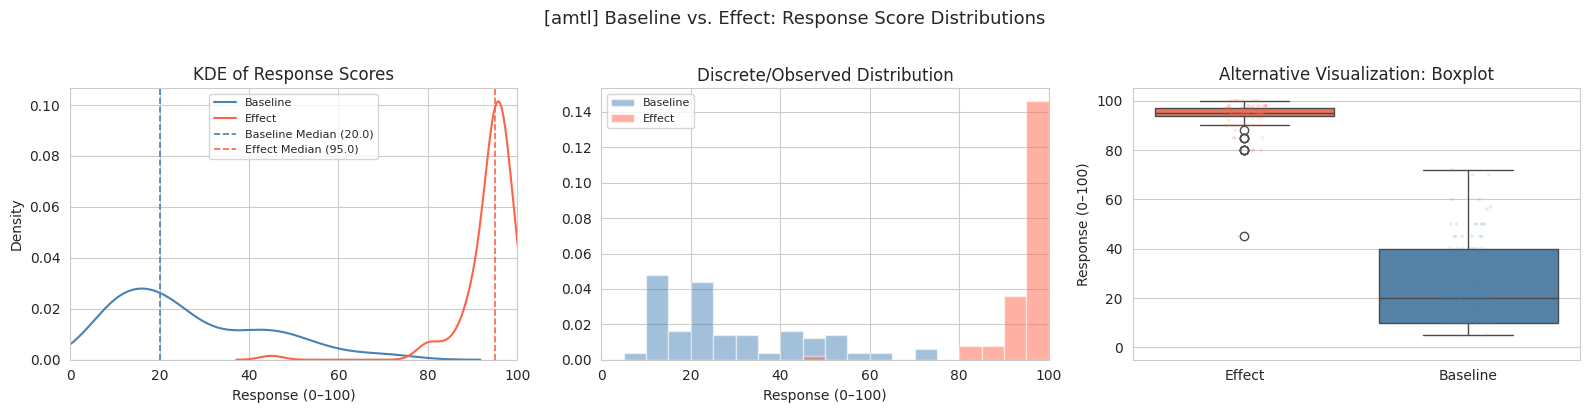

Median of Effect Distribution: 95.00  →  p-value of 0.0000 in right tail of Baseline.
Mean of Effect Distribution: 93.85  →  p-value of 0.0000 in right tail of Baseline.


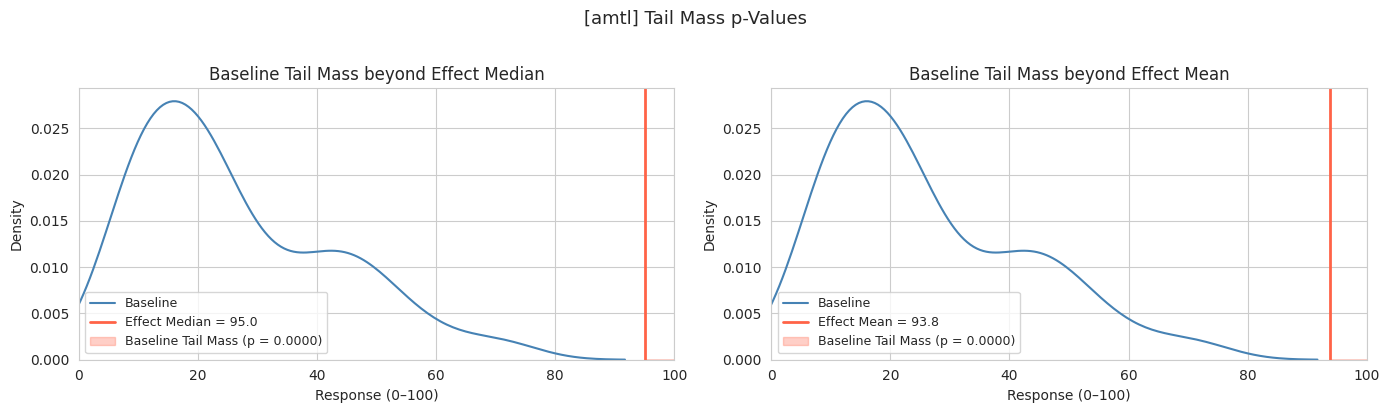

Area of Overlap: 0.0189 → p-Value of 0.0000.


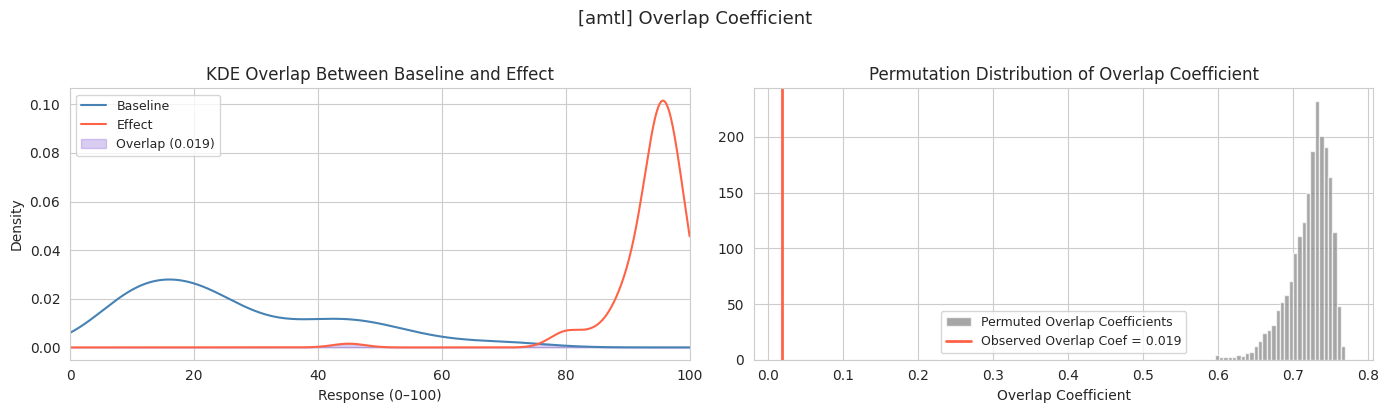


DATASET: 'boxes'
                n   mean  median        std
distribution                               
alt           100  34.46    30.0  16.620797
null          100  31.93    25.0  19.666027


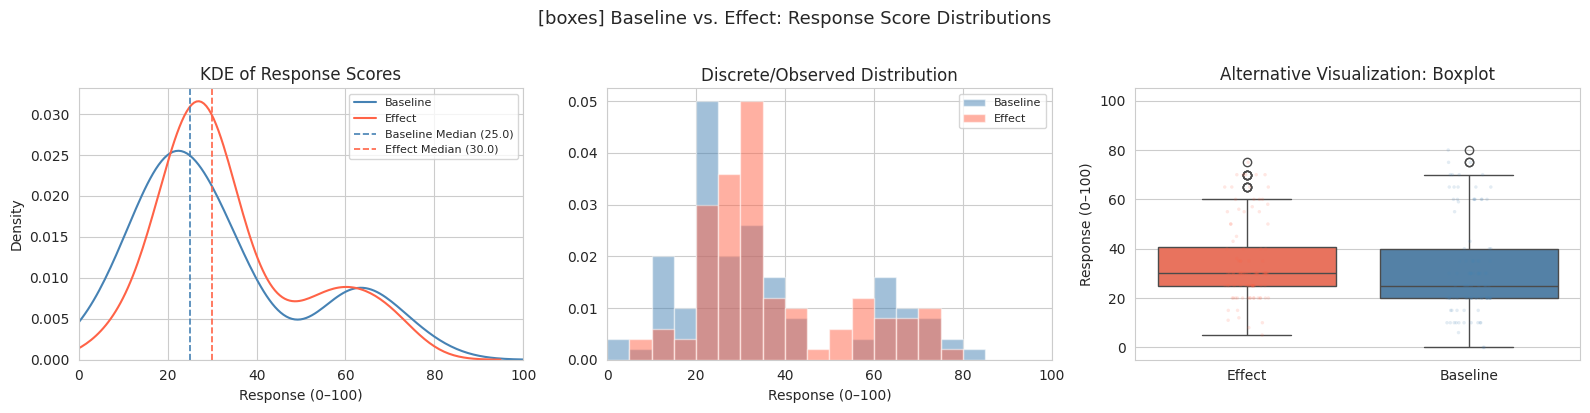

Median of Effect Distribution: 30.00  →  p-value of 0.4700 in right tail of Baseline.
Mean of Effect Distribution: 34.46  →  p-value of 0.3400 in right tail of Baseline.


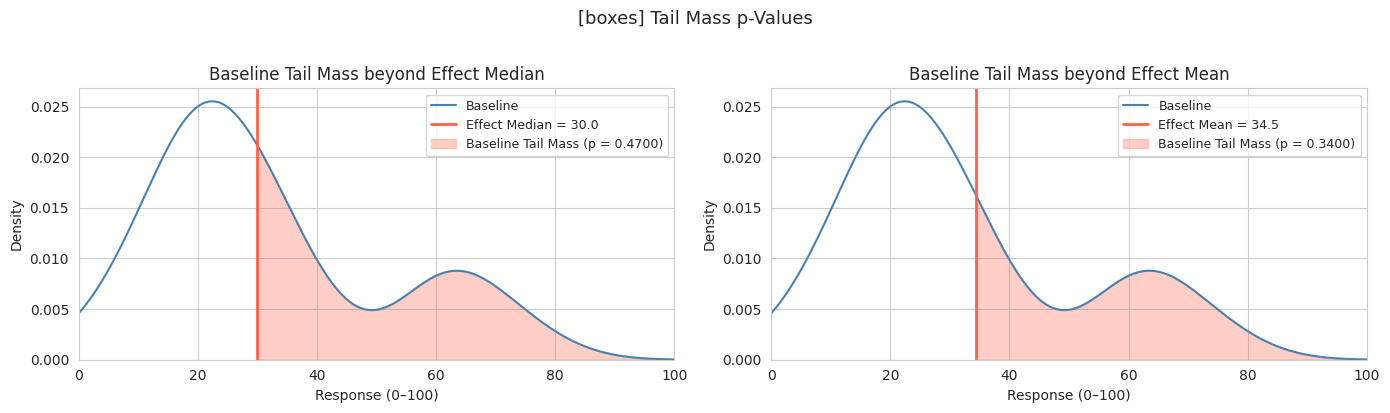

Area of Overlap: 0.8422 → p-Value of 0.0450.


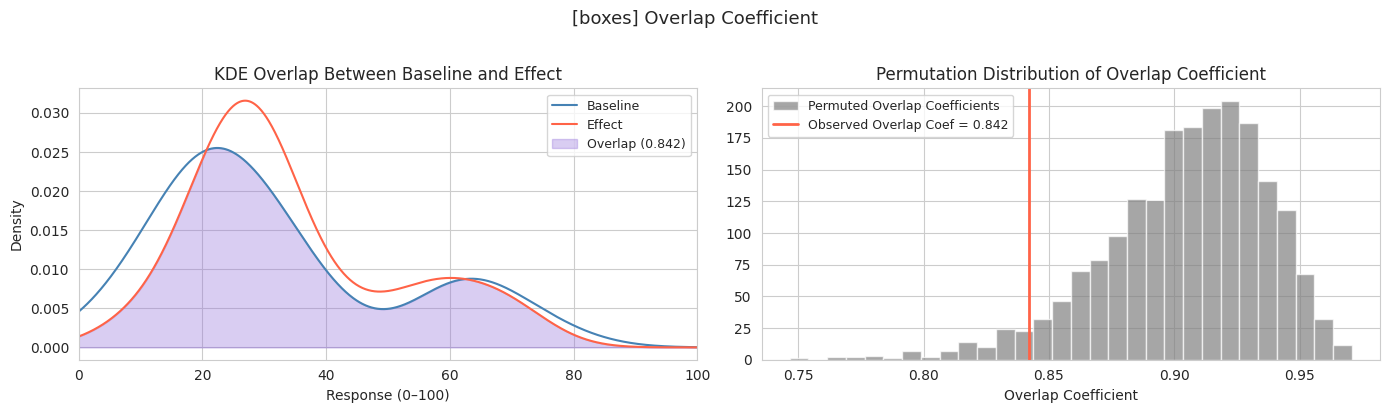


DATASET: 'caschools'
                n   mean  median        std
distribution                               
alt           100  55.81    60.0  19.892994
null          100  17.26    10.0  11.139719


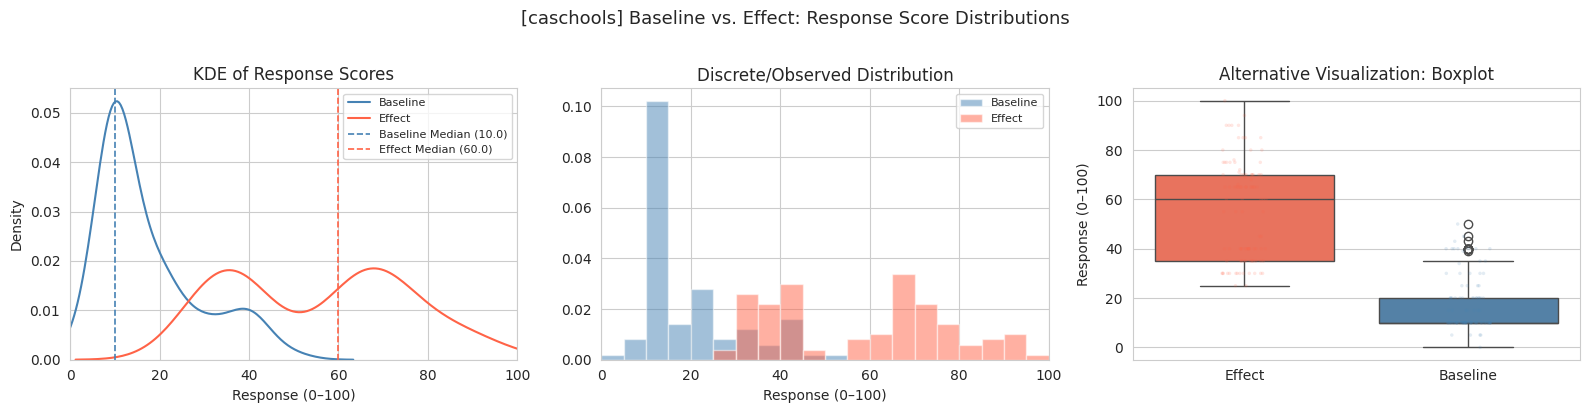

Median of Effect Distribution: 60.00  →  p-value of 0.0000 in right tail of Baseline.
Mean of Effect Distribution: 55.81  →  p-value of 0.0000 in right tail of Baseline.


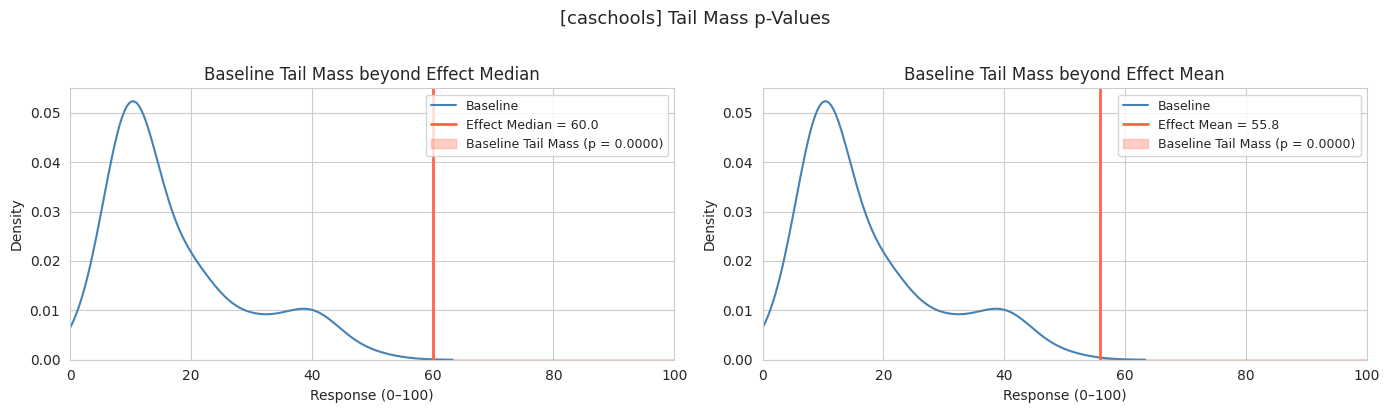

Area of Overlap: 0.2799 → p-Value of 0.0000.


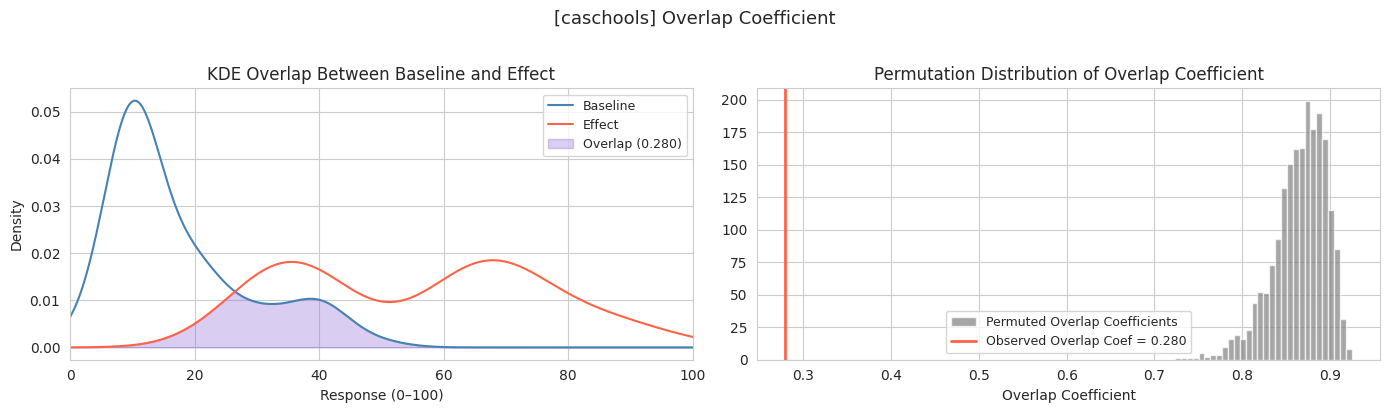


DATASET: 'crofoot'
                n   mean  median       std
distribution                              
alt            25  29.80    30.0  5.492419
null          100  22.63    20.0  6.754953


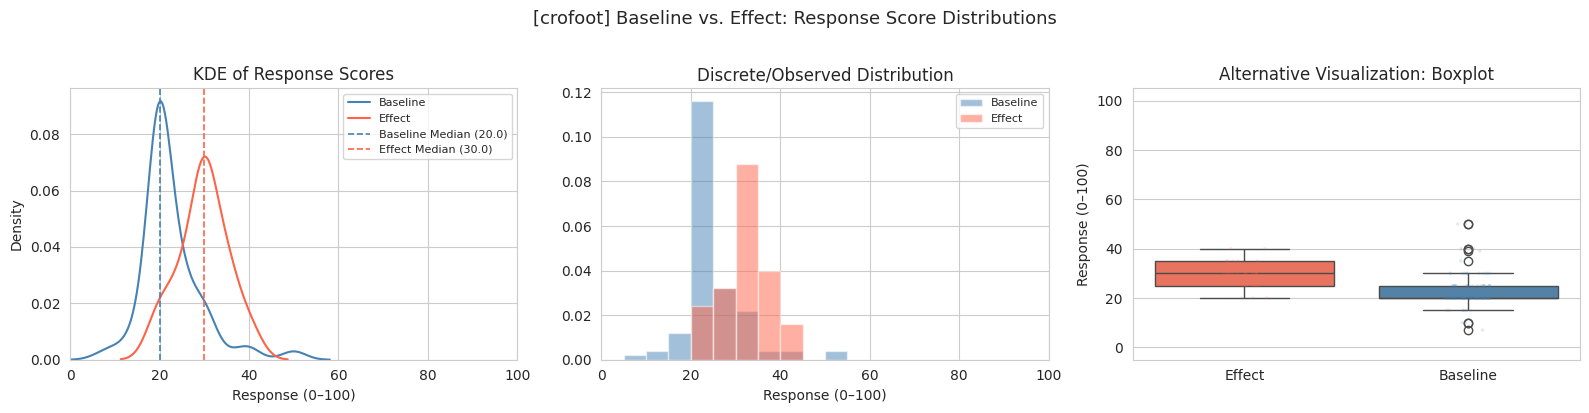

Median of Effect Distribution: 30.00  →  p-value of 0.1700 in right tail of Baseline.
Mean of Effect Distribution: 29.80  →  p-value of 0.1700 in right tail of Baseline.


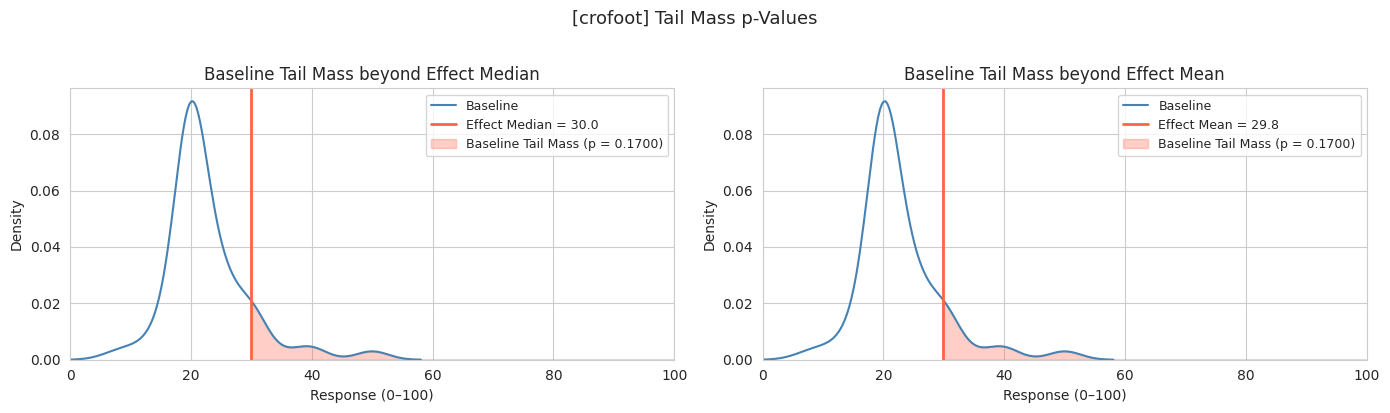

Area of Overlap: 0.4614 → p-Value of 0.0000.


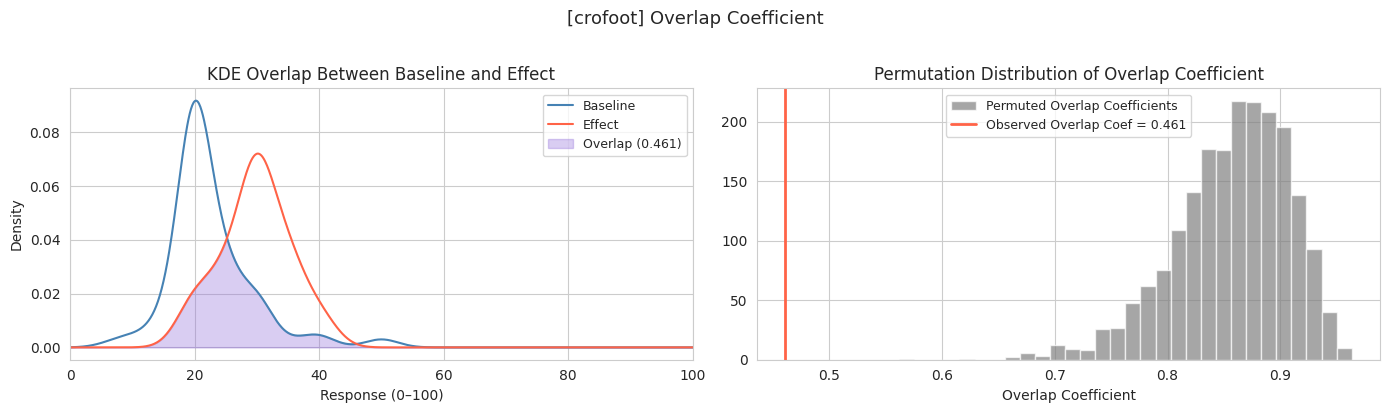

In [5]:
# store summary statistics for each dataset
all_summaries = []

# analyze each dataset
for dataset_name in datasets:
    # get the null and alt scores for this dataset
    sub = df[df["dataset"] == dataset_name]
    null_scores = sub.loc[
        sub["distribution"] == "null", "response"
    ].reset_index(drop=True)
    alt_scores = sub.loc[sub["distribution"] == "alt", "response"].reset_index(
        drop=True
    )

    # skip datasets with too few scores to analyze
    if len(null_scores) < 2 or len(alt_scores) < 2:
        print(f"\n{'=' * 80}")
        print(
            f"DATASET: {dataset_name}  — skipping (null n={len(null_scores)}, alt n={len(alt_scores)})"
        )
        continue

    # ── summary stats ──
    print(f"\n{'=' * 80}")
    print(f"DATASET: '{dataset_name}'")
    # print dataframe of summary stats
    print(
        sub.groupby("distribution")["response"]
        .agg(["count", "mean", "median", "std"])
        .rename(
            columns={
                "count": "n",
                "mean": "mean",
                "median": "median",
                "std": "std",
            }
        )
    )

    # ── distribution plots ──
    # three subplots for KDE, histogram, and box plot
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # plot KDEs with vertical lines for medians
    ax = axes[0]
    sns.kdeplot(
        null_scores, ax=ax, label="Baseline", color="steelblue", common_norm=False
    )
    sns.kdeplot(
        alt_scores,
        ax=ax,
        label="Effect",
        color="tomato",
        common_norm=False,
    )
    ax.axvline(
        null_scores.median(),
        color="steelblue",
        linestyle="--",
        linewidth=1.2,
        label=f"Baseline Median ({null_scores.median():.1f})",
    )
    ax.axvline(
        alt_scores.median(),
        color="tomato",
        linestyle="--",
        linewidth=1.2,
        label=f"Effect Median ({alt_scores.median():.1f})",
    )
    ax.set_title("KDE of Response Scores")
    ax.set_xlabel("Response (0–100)")
    ax.set_xlim(0, 100)
    ax.legend(fontsize=8)

    # plot histograms to show the shape of the discrete distributions
    ax = axes[1]
    bins = range(0, 102, 5)
    ax.hist(
        null_scores,
        bins=bins,
        alpha=0.5,
        color="steelblue",
        label="Baseline",
        density=True,
    )
    ax.hist(
        alt_scores,
        bins=bins,
        alpha=0.5,
        color="tomato",
        label="Effect",
        density=True,
    )
    ax.set_title("Discrete/Observed Distribution")
    ax.set_xlabel("Response (0–100)")
    ax.set_xlim(0, 100)
    ax.legend(fontsize=8)

    # plot boxplots to show simpler version of the dist
    ax = axes[2]
    plot_df = sub[sub["distribution"].isin(["null", "alt"])][
        ["distribution", "response"]
    ]
    sns.boxplot(
        data=plot_df,
        x="distribution",
        y="response",
        hue="distribution",
        palette={"null": "steelblue", "alt": "tomato"},
        legend=False,
        ax=ax,
    )
    sns.stripplot(
        data=plot_df,
        x="distribution",
        y="response",
        hue="distribution",
        palette={"null": "steelblue", "alt": "tomato"},
        alpha=0.15,
        size=2.5,
        jitter=True,
        legend=False,
        ax=ax,
    )
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Effect", "Baseline"])
    ax.set_title("Alternative Visualization: Boxplot")
    ax.set_xlabel("")
    ax.set_ylabel("Response (0–100)")
    ax.set_ylim(-5, 105)

    plt.suptitle(
        f"[{dataset_name}] Baseline vs. Effect: Response Score Distributions",
        y=1.02,
        fontsize=13,
    )
    plt.tight_layout()
    plt.show()

    # ── tail-mass p-values ──
    # use helper functions to get right-tail p-values
    alt_median = alt_scores.median()
    alt_mean = alt_scores.mean()
    p_median = tail_mass_pvalue(null_scores, alt_median)
    p_mean = tail_mass_pvalue(null_scores, alt_mean)

    print(
        f"Median of Effect Distribution: {alt_median:.2f}  →  p-value of {p_median:.4f} in right tail of Baseline."
    )
    print(
        f"Mean of Effect Distribution: {alt_mean:.2f}  →  p-value of {p_mean:.4f} in right tail of Baseline."
    )

    # plot of the null distribution with a vertical line representing the center
    # of the alternative distribution, shading under the null distribution to
    # the right of that line to show the tail mass
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for i, (threshold, p_val, lbl) in enumerate(
        [
            (alt_median, p_median, "Median"),
            (alt_mean, p_mean, "Mean"),
        ]
    ):
        ax = axes[i]
        sns.kdeplot(
            null_scores,
            ax=ax,
            color="steelblue",
            label="Baseline",
            common_norm=False,
        )
        ax.axvline(
            threshold,
            color="tomato",
            linewidth=2,
            linestyle="-",
            label=f"Effect {lbl} = {threshold:.1f}",
        )
        # compute KDE to shade only under the curve beyond the threshold
        kde_null = stats.gaussian_kde(null_scores.to_numpy().astype(float))
        x_fill = np.linspace(threshold, 100, 500)
        y_fill = kde_null(x_fill)
        ax.fill_between(
            x_fill,
            y_fill,
            alpha=0.3,
            color="tomato",
            label=f"Baseline Tail Mass (p = {p_val:.4f})",
        )

        ax.set_title(f"Baseline Tail Mass beyond Effect {lbl}")
        ax.set_xlabel("Response (0–100)")
        ax.set_xlim(0, 100)
        ax.legend(fontsize=9)

    plt.suptitle(f"[{dataset_name}] Tail Mass p-Values", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── overlap coefficient + permutation test ──
    ### OVL = integral of min(f_null, f_alt). Ranges from 0 (no overlap) to 1 (identical).
    # Permutation test to get a p-value: shuffle labels, recompute OVL, see how often we'd get separation this large by chance.
    # use helper function to get the amount of overlap between the distributions
    null_arr = null_scores.to_numpy().astype(float)
    alt_arr = alt_scores.to_numpy().astype(float)
    observed_ovl = overlap_coefficient(null_arr, alt_arr)
    p_ovl, perm_ovls = overlap_permutation_test(null_arr, alt_arr, observed_ovl)

    print(f"Area of Overlap: {observed_ovl:.4f} → p-Value of {p_ovl:.4f}.")

    # create side-by-side plot of overlap area and permutation distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # plot the KDEs of the two distributions with the overlap area shaded
    ax = axes[0]
    kde_null = stats.gaussian_kde(null_arr)
    kde_alt = stats.gaussian_kde(alt_arr)
    y_null = kde_null(X_GRID)
    y_alt = kde_alt(X_GRID)
    ax.plot(X_GRID, y_null, color="steelblue", label="Baseline")
    ax.plot(X_GRID, y_alt, color="tomato", label="Effect")
    ax.fill_between(
        X_GRID,
        np.minimum(y_null, y_alt),
        alpha=0.35,
        color="mediumpurple",
        label=f"Overlap ({observed_ovl:.3f})",
    )
    ax.set_title("KDE Overlap Between Baseline and Effect")
    ax.set_xlabel("Response (0–100)")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 100)
    ax.legend(fontsize=9)

    # plot histogram of permuted OVLs with vertical line for observed OVL
    ax = axes[1]
    ax.hist(
        perm_ovls,
        bins=30,
        color="gray",
        alpha=0.7,
        label="Permuted Overlap Coefficients",
    )
    ax.axvline(
        observed_ovl,
        color="tomato",
        linewidth=2,
        linestyle="-",
        label=f"Observed Overlap Coef = {observed_ovl:.3f}",
    )
    ax.set_title("Permutation Distribution of Overlap Coefficient")
    ax.set_xlabel("Overlap Coefficient")
    ax.legend(fontsize=9)

    plt.suptitle(f"[{dataset_name}] Overlap Coefficient", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── collect summary row ──
    all_summaries.append(
        {
            "dataset": dataset_name,
            "null_n": len(null_scores),
            "alt_n": len(alt_scores),
            "null_mean": null_scores.mean(),
            "alt_mean": alt_scores.mean(),
            "null_median": null_scores.median(),
            "alt_median": alt_scores.median(),
            "p_tail_median": p_median,
            "p_tail_mean": p_mean,
            "ovl": observed_ovl,
            "p_ovl": p_ovl,
        }
    )

In [6]:
# aggregate summary table
summary_df = pd.DataFrame(all_summaries)
summary_df

,dataset,null_n,alt_n,null_mean,alt_mean,null_median,alt_median,p_tail_median,p_tail_mean,ovl,p_ovl
0,affairs,100,100,30.45,20.53,25.0,15.0,0.85,0.53,0.745854,0.000
1,amtl,100,100,26.50,93.85,20.0,95.0,0.00,0.00,0.018919,0.000
2,boxes,100,100,31.93,34.46,25.0,30.0,0.47,0.34,0.842178,0.045
3,caschools,100,100,17.26,55.81,10.0,60.0,0.00,0.00,0.279889,0.000
4,crofoot,100,25,22.63,29.80,20.0,30.0,0.17,0.17,0.461436,0.000


# Blocked Permutation Test

We want to test whether the LLM assigns higher scores when real signal is present
(alt) vs when relationships are broken (null).

This means we have 2 conditions (alt vs null) crossed with perturbation types, with 20 runs
per cell. 
We consider the perturbation types to ensure exchangeability, which is needed 
for permutation tests.

Test statistic:
$$T = \frac{1}{K}\sum_{k=1}^{K}\left(\hat{\mu}^{(k)}_{\text{alt}} - \hat{\mu}^{(k)}_{\text{null}}\right),$$

where $\hat{\mu}$ is either the median or mean within each block. We compare them below. 
Averaging per-block differences gives each perturbation type equal weight
to avoid issues from pooling across heterogeneous blocks.

Within each perturbation block, we randomly shuffle the alt/null labels, recompute $T$, and repeat.

For the p-value, we use the small-sample correction to avoid p-values equal to zero:
$$p = \frac{\#\{T \ge T_{\text{obs}}\} + 1}{B + 1},$$

where $B$ is the number of permutations.

In [7]:
import sys

_scripts_dir = str(Path("..").resolve() / "scripts")
if _scripts_dir not in sys.path:
    sys.path.insert(0, _scripts_dir)

from statistical_tests import blocked_permutation_test, stratified_diff

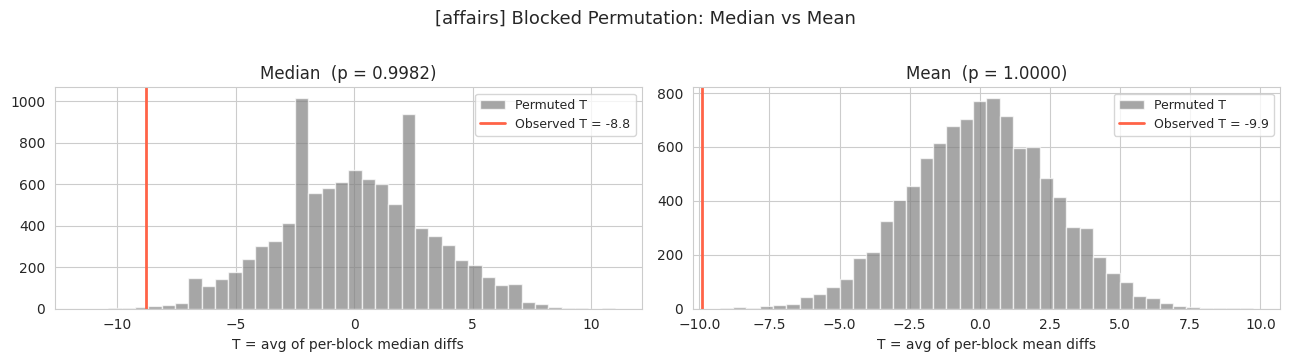

affairs: median T=-8.80 p=0.9982 | mean T=-9.92 p=1.0000


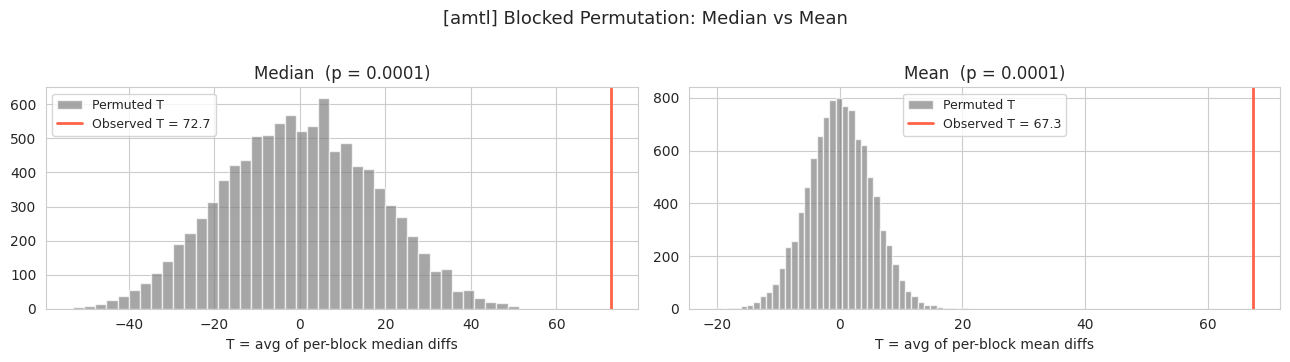

amtl: median T=72.70 p=0.0001 | mean T=67.35 p=0.0001


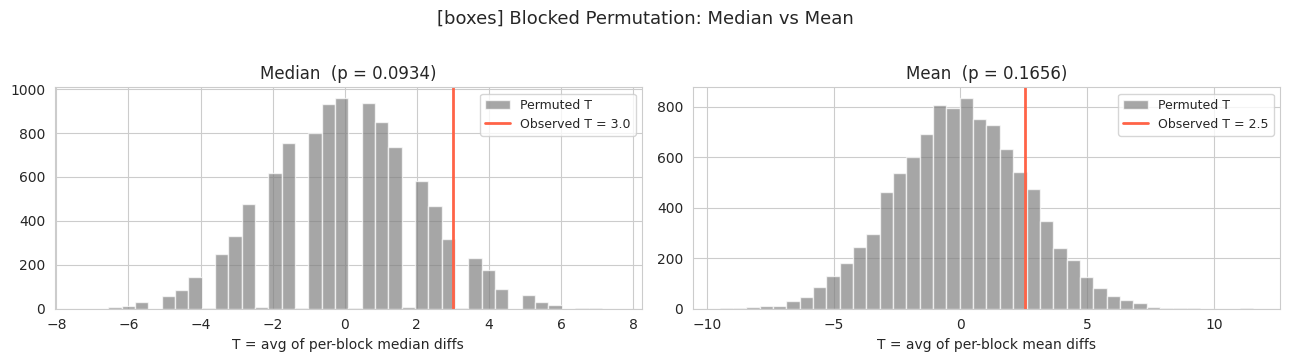

boxes: median T=3.00 p=0.0934 | mean T=2.53 p=0.1656


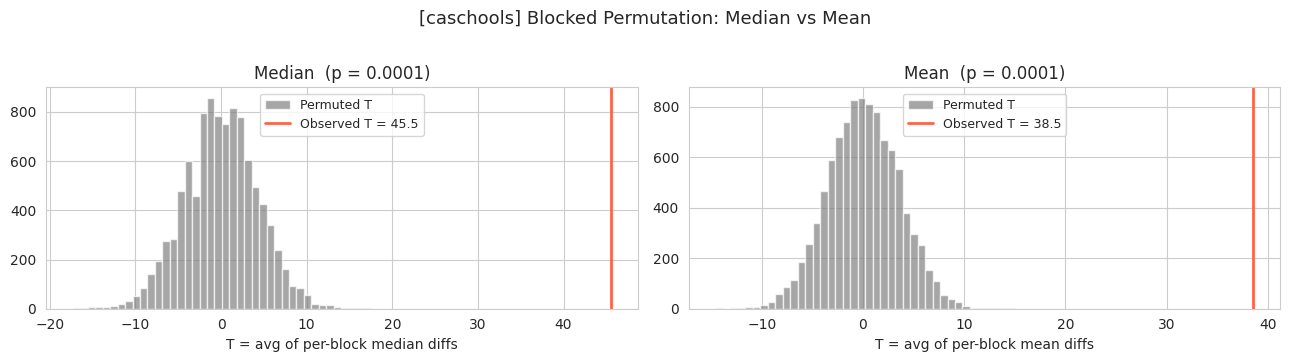

caschools: median T=45.50 p=0.0001 | mean T=38.55 p=0.0001


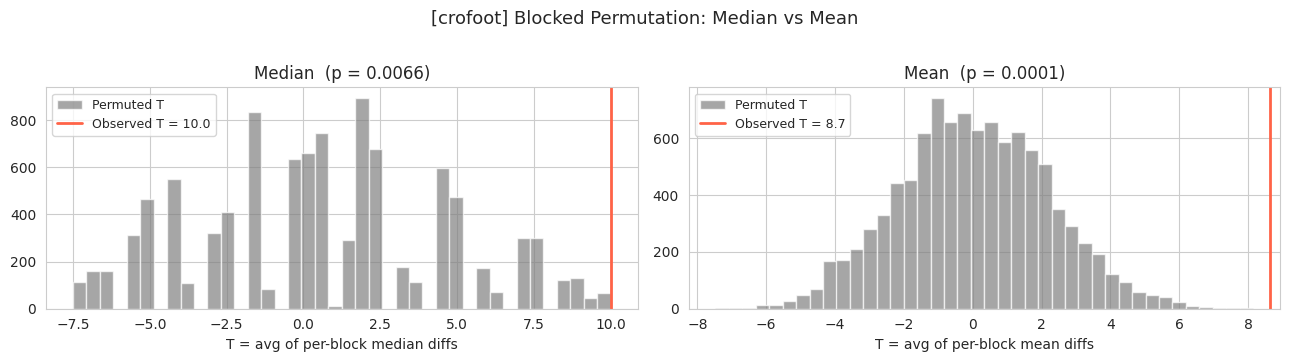

crofoot: median T=10.00 p=0.0066 | mean T=8.65 p=0.0001


,dataset,T_median,p_median,T_mean,p_mean
0,affairs,-8.8,0.998200,-9.92,1.000000
1,amtl,72.7,0.000100,67.35,0.000100
2,boxes,3.0,0.093391,2.53,0.165583
3,caschools,45.5,0.000100,38.55,0.000100
4,crofoot,10.0,0.006599,8.65,0.000100


In [8]:
blocked_results = []
perm_rng = np.random.default_rng(42)

for dataset_name in datasets:
    sub = df[df["dataset"] == dataset_name]
    t_median, p_median, perm_median = blocked_permutation_test(sub, agg=np.median, rng=perm_rng)
    t_mean, p_mean, perm_mean = blocked_permutation_test(sub, agg=np.mean, rng=perm_rng)

    blocked_results.append({
        "dataset": dataset_name,
        "T_median": t_median,
        "p_median": p_median,
        "T_mean": t_mean,
        "p_mean": p_mean,
    })

    fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

    for ax, perm_ts, t_obs, p_val, label in [
        (axes[0], perm_median, t_median, p_median, "Median"),
        (axes[1], perm_mean, t_mean, p_mean, "Mean"),
    ]:
        ax.hist(perm_ts, bins=40, color="gray", alpha=0.7, label="Permuted T")
        ax.axvline(t_obs, color="tomato", linewidth=2, label=f"Observed T = {t_obs:.1f}")
        ax.set_xlabel(f"T = avg of per-block {label.lower()} diffs")
        ax.set_title(f"{label}  (p = {p_val:.4f})")
        ax.legend(fontsize=9)

    plt.suptitle(f"[{dataset_name}] Blocked Permutation: Median vs Mean", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"{dataset_name}: median T={t_median:.2f} p={p_median:.4f} | mean T={t_mean:.2f} p={p_mean:.4f}")

pd.DataFrame(blocked_results)